--- Data Overview ---
   index    stream  Zscore district_rank  island_rank  al_year  \
0      0      ARTS  -.3550    4336 (NEW)  64994 (NEW)     2020   
1      1      ARTS  -.2648    4154 (NEW)  62338 (NEW)     2020   
2      2  COMMERCE  -.4760    6910 (NEW)  37307 (NEW)     2020   
3      3  COMMERCE  -.1012    5678 (NEW)  30449 (NEW)     2020   
4      4  COMMERCE   .6014    3269 (NEW)  17010 (NEW)     2020   

                sub1 sub1_r               sub2 sub2_r        sub3 sub3_r  \
0  POLITICAL SCIENCE      S  DANCING(BHARATHA)      C       TAMIL      S   
1  POLITICAL SCIENCE      S     CARNATIC MUSIC      C       TAMIL      C   
2          ECONOMICS      S   BUSINESS STUDIES      S  ACCOUNTING      S   
3          ECONOMICS      C   BUSINESS STUDIES      C  ACCOUNTING      S   
4          ECONOMICS      C   BUSINESS STUDIES      C  ACCOUNTING      B   

  cgt_r ge_r syllabus birth_day birth_month birth_year  gender  
0   056    S      new        31         May       2001  fem

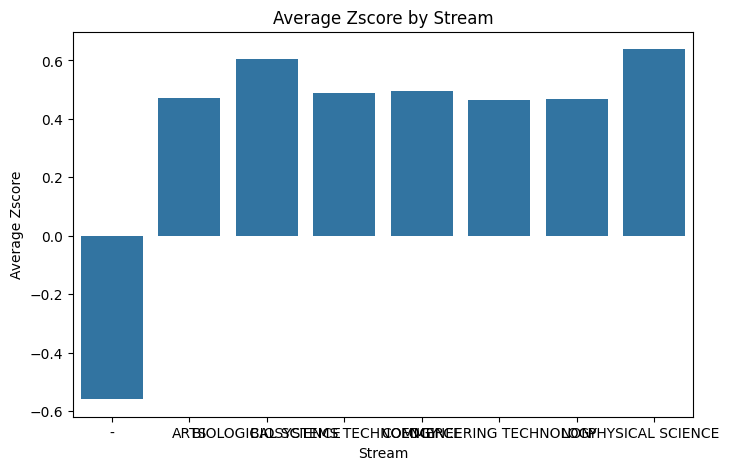

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. EXTRACT ---
# Read the uploaded CSV file
df = pd.read_csv('/content/2020_al_data_kaggle_upload_new_old_syllabi.csv')

print("--- Data Overview ---")
print(df.head()) # Display the first 5 rows


# --- 2. TRANSFORM ---
# 1. Remove missing values (nulls)
df = df.dropna()

# 2. Convert data types if needed (e.g., force text values into numbers)
# Original 'Sales', 'Price', 'Quantity', 'Category' columns not found in this dataset.
# Adapting to available columns: using 'stream' for grouping and 'Zscore' for numerical analysis.
df['Zscore'] = pd.to_numeric(df['Zscore'], errors='coerce')

# 3. Create a new calculated column for analysis (or use existing if suitable)
# 'Total_Revenue' calculation removed as 'Price' and 'Quantity' are not present.
# We will directly use 'Zscore' for aggregation.


# --- 3. LOAD / ANALYTICS ---
# Group data by 'stream' and summarize 'Zscore'
analytics_summary = df.groupby('stream')['Zscore'].mean().reset_index() # Using mean for Zscore as sum might not be meaningful

print("\n--- Analytics Summary ---")
print(analytics_summary)

# Export the processed summary to a new CSV file
analytics_summary.to_csv('final_analytics.csv', index=False)


# --- 4. DATA VISUALIZATION ---
plt.figure(figsize=(8, 5))
sns.barplot(data=analytics_summary, x='stream', y='Zscore')
plt.title('Average Zscore by Stream')
plt.xlabel('Stream')
plt.ylabel('Average Zscore')
plt.show()

## Data Cleaning Steps

In [ ]:
# 1. Remove missing values (nulls) from the DataFrame
df = df.dropna()

# 2. Convert the 'Zscore' column to a numeric data type.
#    'errors="coerce"' will turn any non-numeric values into NaN (Not a Number).
#    This step ensures all Zscore values are numbers after removing NaNs.
df.loc[:, 'Zscore'] = pd.to_numeric(df['Zscore'], errors='coerce')

print("Data cleaning steps applied:")
print(" - Rows with any missing values were removed.")
print(" - 'Zscore' column was converted to numeric, coercing errors.")

Data cleaning steps applied:
 - Rows with any missing values were removed.
 - 'Zscore' column was converted to numeric, coercing errors.


## Summary Statistics for Numerical Columns

In [ ]:
display(df.describe())

,index,Zscore,al_year
count,231874.000000,231874.000000,231874.0
mean,161307.691130,0.305896,2020.0
std,95505.620665,0.763786,0.0
min,0.000000,-1.938300,2020.0
25%,78878.250000,-0.299700,2020.0
50%,159466.500000,0.222300,2020.0
75%,242810.500000,0.853300,2020.0
max,337552.000000,3.558300,2020.0


## Feature Engineering

Let's extract more meaningful features from the existing columns. We will start by extracting numerical ranks from `district_rank` and `island_rank` and then create an `Age` column from the birth date information.

In [13]:
import re

# Extract numerical part from 'district_rank'
df['district_rank_numeric'] = df['district_rank'].apply(lambda x: int(re.search(r'\d+', str(x)).group()) if re.search(r'\d+', str(x)) else None)

# Extract numerical part from 'island_rank'
df['island_rank_numeric'] = df['island_rank'].apply(lambda x: int(re.search(r'\d+', str(x)).group()) if re.search(r'\d+', str(x)) else None)

print("Extracted numerical ranks:")
display(df[['district_rank', 'district_rank_numeric', 'island_rank', 'island_rank_numeric']].head())

Extracted numerical ranks:


,district_rank,district_rank_numeric,island_rank,island_rank_numeric
0,4336 (NEW),4336.0,64994 (NEW),64994.0
1,4154 (NEW),4154.0,62338 (NEW),62338.0
2,6910 (NEW),6910.0,37307 (NEW),37307.0
3,5678 (NEW),5678.0,30449 (NEW),30449.0
4,3269 (NEW),3269.0,17010 (NEW),17010.0


### Numerical Grade Extraction

To better analyze student performance, we will convert the letter grades (A, B, C, S) into numerical values. This will allow us to calculate metrics like average grade points.

In [23]:
grade_mapping = {
    'A': 4,
    'B': 3,
    'C': 2,
    'S': 1,
    'W': 0, # Assuming 'W' for withdrawn or other non-standard grades as 0
    'F': 0, # Assuming 'F' for fail as 0
    'X': 0, # Placeholder for any other unexpected grades
    None: None, # Handle explicit None if present
    'nan': None # Handle string 'nan' if present after .dropna()
}

# Apply the mapping to all relevant grade columns
for col in ['sub1_r', 'sub2_r', 'sub3_r', 'cgt_r', 'ge_r']:
    if col == 'cgt_r':
        # For 'cgt_r', convert directly to numeric as it contains numerical strings
        df[f'{col}_numeric'] = pd.to_numeric(df[col], errors='coerce')
    else:
        # For other grade columns, map letter grades to numeric values
        df[f'{col}_numeric'] = df[col].astype(str).str.upper().map(grade_mapping)

print("Numerical grades extracted:")
display(df[['sub1_r', 'sub1_r_numeric', 'sub2_r', 'sub2_r_numeric', 'sub3_r', 'sub3_r_numeric', 'cgt_r', 'cgt_r_numeric', 'ge_r', 'ge_r_numeric']].head())

Numerical grades extracted:


,sub1_r,sub1_r_numeric,sub2_r,sub2_r_numeric,sub3_r,sub3_r_numeric,cgt_r,cgt_r_numeric,ge_r,ge_r_numeric
0,S,1.0,C,2.0,S,1.0,056,56.0,S,1.0
1,S,1.0,C,2.0,C,2.0,032,32.0,C,2.0
2,S,1.0,S,1.0,S,1.0,050,50.0,S,1.0
3,C,2.0,C,2.0,S,1.0,034,34.0,S,1.0
4,C,2.0,C,2.0,B,3.0,036,36.0,S,1.0


In [22]:
# Calculate a total or average grade point for overall student performance
# We'll consider only the main subject grades (sub1_r, sub2_r, sub3_r) for this example

df['total_subject_grade_points'] = df[['sub1_r_numeric', 'sub2_r_numeric', 'sub3_r_numeric']].sum(axis=1)

# Calculate average grade point per student for the main subjects
# Exclude NaN values from the mean calculation
df['average_subject_grade_point'] = df[['sub1_r_numeric', 'sub2_r_numeric', 'sub3_r_numeric']].mean(axis=1)

print("Total and Average Subject Grade Points calculated:")
display(df[['sub1_r_numeric', 'sub2_r_numeric', 'sub3_r_numeric', 'total_subject_grade_points', 'average_subject_grade_point']].head())

Total and Average Subject Grade Points calculated:


,sub1_r_numeric,sub2_r_numeric,sub3_r_numeric,total_subject_grade_points,average_subject_grade_point
0,1.0,2.0,1.0,4.0,1.333333
1,1.0,2.0,2.0,5.0,1.666667
2,1.0,1.0,1.0,3.0,1.000000
3,2.0,2.0,1.0,5.0,1.666667
4,2.0,2.0,3.0,7.0,2.333333


### Current State of the DataFrame after all Cleaning and Transformations

To confirm that all requested cleaning and transformations have been applied to the data loaded from the CSV, let's review the DataFrame's information and its first few rows again.

In [24]:
print("Updated DataFrame Information (df.info()):")
df.info()

print("\nFirst 5 rows of the transformed DataFrame (df.head()):")
display(df.head())

Updated DataFrame Information (df.info()):
<class 'pandas.core.frame.DataFrame'>
Index: 231874 entries, 0 to 337552
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   index                        231874 non-null  int64         
 1   stream                       231874 non-null  object        
 2   Zscore                       231874 non-null  float64       
 3   district_rank                231874 non-null  object        
 4   island_rank                  231874 non-null  object        
 5   al_year                      231874 non-null  int64         
 6   sub1                         231874 non-null  object        
 7   sub1_r                       231874 non-null  object        
 8   sub2                         231874 non-null  object        
 9   sub2_r                       231874 non-null  object        
 10  sub3                         231874 non-null  object  

,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,...,birth_date,age,birth_month_numeric,sub1_r_numeric,sub2_r_numeric,sub3_r_numeric,cgt_r_numeric,ge_r_numeric,total_subject_grade_points,average_subject_grade_point
0,0,ARTS,-0.3550,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,...,2001-05-31,19.0,5.0,1.0,2.0,1.0,56.0,1.0,4.0,1.333333
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,...,2002-01-13,18.0,1.0,1.0,2.0,2.0,32.0,2.0,5.0,1.666667
2,2,COMMERCE,-0.4760,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,...,2001-08-16,19.0,8.0,1.0,1.0,1.0,50.0,1.0,3.0,1.000000
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,...,2001-08-16,19.0,8.0,2.0,2.0,1.0,34.0,1.0,5.0,1.666667
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,...,2000-08-07,20.0,8.0,2.0,2.0,3.0,36.0,1.0,7.0,2.333333


### Saving the Transformed Data to a New CSV File

Now that all the cleaning, feature engineering, and transformations have been applied, we can save the resulting DataFrame `df` to a new CSV file. This 'extracted CSV' will contain all the processed data, ready for further analysis or modeling.

In [25]:
# Save the transformed DataFrame to a new CSV file
df.to_csv('transformed_al_data.csv', index=False)

print("Transformed data saved to 'transformed_al_data.csv'")

Transformed data saved to 'transformed_al_data.csv'
